<a href="https://colab.research.google.com/github/jungeun1228/2026_08_Tahoe-100M_scRNA-seq-analysis/blob/main/03_Tahoe_Pseudobulk_DE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install -q anndata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


In [ ]:
import anndata as ad
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Tahoe_project/anndata")

files = {
    "HT29": "HT29_raw.h5ad",
    "PANC1": "PANC1_raw.h5ad",
    "HepG2_C3A": "HepG2_C3A_raw.h5ad",
    "A172": "A172_raw.h5ad",
    "BT474": "BT474_raw.h5ad"
}

required = [
    "sample",
    "plate",
    "drug",
    "concentration",
    "is_control"
]

all_meta = []

for cell_line, filename in files.items():

    a = ad.read_h5ad(BASE / filename, backed="r")

    print(f"\n{cell_line}: {a.n_obs:,} cells")
    print("Metadata columns:", a.obs.columns.tolist())

    missing = [c for c in required if c not in a.obs.columns]

    if missing:
        a.file.close()
        raise ValueError(
            f"{cell_line}: Missing metadata columns: {missing}"
        )

    meta = a.obs[required].copy()
    meta["cell_line"] = cell_line

    all_meta.append(meta)

    a.file.close()

meta = pd.concat(all_meta, ignore_index=True)

# 하나의 cell line × plate × sample × treatment 단위로 정리
sample_table = (
    meta.groupby(
        [
            "cell_line",
            "plate",
            "sample",
            "drug",
            "concentration",
            "is_control"
        ],
        observed=True,
        dropna=False
    )
    .size()
    .reset_index(name="n_cells")
)

# 각 condition의 sample 수와 plate 수 확인
replicate_table = (
    sample_table.groupby(
        [
            "cell_line",
            "drug",
            "concentration",
            "is_control"
        ],
        observed=True,
        dropna=False
    )
    .agg(
        n_sample_plate_groups=("n_cells", "size"),
        n_sample_ids=("sample", "nunique"),
        n_plates=("plate", "nunique"),
        n_cells=("n_cells", "sum")
    )
    .reset_index()
)

print("\nTotal cells:", len(meta))
print("Pseudobulk candidate groups:", len(sample_table))

print("\nControl annotation:")
print(meta["is_control"].value_counts(dropna=False))

print("\nControl drug labels:")
print(
    meta.loc[
        meta["is_control"].astype(str).str.lower().isin(
            ["true", "1"]
        ),
        "drug"
    ].value_counts(dropna=False)
)

print("\nTotal cells:", len(meta))
print("Pseudobulk candidate groups:", len(sample_table))

display(sample_table.head(15))
display(replicate_table.head(15))


HT29: 142,046 cells
Metadata columns: ['cell_id', 'sample', 'drug', 'plate', 'cell_line_id', 'moa_fine', 'concentration', 'is_control', 'cell_line']

PANC1: 288,084 cells
Metadata columns: ['cell_id', 'sample', 'drug', 'plate', 'cell_line_id', 'moa_fine', 'concentration', 'is_control', 'cell_line']

HepG2_C3A: 77,915 cells
Metadata columns: ['cell_id', 'sample', 'drug', 'plate', 'cell_line_id', 'moa_fine', 'concentration', 'is_control', 'cell_line']

A172: 151,159 cells
Metadata columns: ['cell_id', 'sample', 'drug', 'plate', 'cell_line_id', 'moa_fine', 'concentration', 'is_control', 'cell_line']

BT474: 82,804 cells
Metadata columns: ['cell_id', 'sample', 'drug', 'plate', 'cell_line_id', 'moa_fine', 'concentration', 'is_control', 'cell_line']

Total cells: 742008
Pseudobulk candidate groups: 420

Control annotation:
is_control
False    479695
True     262313
Name: count, dtype: int64

Control drug labels:
drug
DMSO_TF                         262313
Apalutamide                        

,cell_line,plate,sample,drug,concentration,is_control,n_cells
0,A172,plate1,smp_1589,DMSO_TF,NaN,True,2070
1,A172,plate1,smp_1590,DMSO_TF,NaN,True,2710
2,A172,plate2,smp_1672,Methylprednisolone succinate,0.50,False,859
3,A172,plate2,smp_1685,DMSO_TF,NaN,True,3935
4,A172,plate2,smp_1686,DMSO_TF,NaN,True,3424
5,A172,plate3,smp_1768,Methylprednisolone succinate,5.00,False,963
6,A172,plate3,smp_1781,DMSO_TF,NaN,True,1853
7,A172,plate3,smp_1782,DMSO_TF,NaN,True,1401
8,A172,plate4,smp_1784,Chlorhexidine (diacetate),0.05,False,2160
9,A172,plate4,smp_1824,Thymol,0.05,False,1176


,cell_line,drug,concentration,is_control,n_sample_plate_groups,n_sample_ids,n_plates,n_cells
0,A172,Apalutamide,0.05,False,1,1,1,883
1,A172,Apalutamide,0.50,False,1,1,1,2374
2,A172,Apalutamide,5.00,False,1,1,1,838
3,A172,Bicalutamide,0.05,False,1,1,1,1917
4,A172,Bicalutamide,0.50,False,1,1,1,1163
5,A172,Bicalutamide,5.00,False,1,1,1,3087
6,A172,Carbidopa (monohydrate),0.05,False,1,1,1,2936
7,A172,Carbidopa (monohydrate),0.50,False,1,1,1,1531
8,A172,Carbidopa (monohydrate),5.00,False,1,1,1,2137
9,A172,Chlorhexidine (diacetate),0.05,False,1,1,1,2160


In [ ]:
# Treatment replication & matched DMSO audit

# 1. 기존 그룹의 세포 수 일치 여부
assert sample_table["n_cells"].sum() == len(meta)

# 2. Control annotation 일치 여부
control_check = (
    sample_table["is_control"]
    == sample_table["drug"].astype(str).eq("DMSO_TF")
)

print("Control annotation consistent:", control_check.all())

# 3. Treatment / Control 분리
treat = sample_table.loc[
    ~sample_table["is_control"]
].copy()

dmso = sample_table.loc[
    sample_table["is_control"]
].copy()

print("\nTreatment groups:", len(treat))
print("DMSO groups:", len(dmso))

# 4. Cell line × plate별 DMSO 구성
dmso_plate = (
    dmso.groupby(
        ["cell_line", "plate"],
        observed=True
    )
    .agg(
        n_dmso_samples=("sample", "nunique"),
        n_dmso_cells=("n_cells", "sum")
    )
    .reset_index()
)

print("\nDMSO sample distribution:")
print(dmso_plate["n_dmso_samples"].value_counts().sort_index())

# 5. Treatment에 동일 cell line / plate DMSO 연결
matched = treat.merge(
    dmso_plate,
    on=["cell_line", "plate"],
    how="left",
    validate="many_to_one"
)

missing = matched[
    matched["n_dmso_samples"].isna()
]

print("\nTreatment groups without matched DMSO:", len(missing))

if len(missing) > 0:
    display(missing)

# 6. Treatment condition별 반복 구조 요약
condition_audit = (
    matched.groupby(
        ["cell_line", "drug", "concentration"],
        observed=True
    )
    .agg(
        n_treatment_groups=("sample", "size"),
        n_treatment_samples=("sample", "nunique"),
        n_treatment_plates=("plate", "nunique"),
        n_treatment_cells=("n_cells", "sum"),
        n_plates_with_dmso=(
            "n_dmso_samples",
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

print("\nUnique treatment conditions:", len(condition_audit))

print("\nTreatment replication distribution:")
print(
    condition_audit["n_treatment_groups"]
    .value_counts()
    .sort_index()
)

print("\nReplication by cell line:")
display(
    pd.crosstab(
        condition_audit["cell_line"],
        condition_audit["n_treatment_groups"]
    )
)

print("\nConditions with multiple plates:")
display(
    condition_audit.loc[
        condition_audit["n_treatment_plates"] > 1
    ].sort_values(
        ["cell_line", "drug", "concentration"]
    )
)

print("\nDMSO matching summary:")
display(
    dmso_plate.groupby("cell_line").agg(
        n_plates=("plate", "nunique"),
        n_dmso_samples=("n_dmso_samples", "sum"),
        n_dmso_cells=("n_dmso_cells", "sum")
    )
)

print("\nSmallest pseudobulk candidate groups:")
display(
    sample_table.sort_values("n_cells").head(15)
)

Control annotation consistent: True

Treatment groups: 280
DMSO groups: 140

DMSO sample distribution:
n_dmso_samples
2    70
Name: count, dtype: int64

Treatment groups without matched DMSO: 0

Unique treatment conditions: 255

Treatment replication distribution:
n_treatment_groups
1    230
2     25
Name: count, dtype: int64

Replication by cell line:


n_treatment_groups,1,2
cell_line,,
A172,46,5
BT474,46,5
HT29,46,5
HepG2_C3A,46,5
PANC1,46,5



Conditions with multiple plates:


,cell_line,drug,concentration,n_treatment_groups,n_treatment_samples,n_treatment_plates,n_treatment_cells,n_plates_with_dmso
10,A172,Chlorhexidine (diacetate),0.5,2,2,2,4371,2
11,A172,Chlorhexidine (diacetate),5.0,2,2,2,5251,2
44,A172,Thymol,5.0,2,2,2,3352,2
47,A172,Triamcinolone,5.0,2,2,2,3514,2
50,A172,Triclosan,5.0,2,2,2,4517,2
61,BT474,Chlorhexidine (diacetate),0.5,2,2,2,2497,2
62,BT474,Chlorhexidine (diacetate),5.0,2,2,2,2854,2
95,BT474,Thymol,5.0,2,2,2,1790,2
98,BT474,Triamcinolone,5.0,2,2,2,1853,2
101,BT474,Triclosan,5.0,2,2,2,2481,2



DMSO matching summary:


,n_plates,n_dmso_samples,n_dmso_cells
cell_line,,,
A172,14,28,56447
BT474,14,28,31009
HT29,14,28,50552
HepG2_C3A,14,28,29046
PANC1,14,28,95259



Smallest pseudobulk candidate groups:


,cell_line,plate,sample,drug,concentration,is_control,n_cells
296,HepG2_C3A,plate9,smp_2353,Niclosamide (olamine),5.00,False,120
128,BT474,plate9,smp_2353,Niclosamide (olamine),5.00,False,127
280,HepG2_C3A,plate7,smp_2146,Menadione,0.05,False,236
307,HepG2_C3A,plate11,smp_2461,Omeprazole,0.50,False,274
283,HepG2_C3A,plate7,smp_2165,DMSO_TF,NaN,True,282
294,HepG2_C3A,plate9,smp_2338,Menadione,5.00,False,287
293,HepG2_C3A,plate9,smp_2331,Fluvoxamine,5.00,False,297
311,HepG2_C3A,plate11,smp_2515,Citalopram (hydrobromide),0.50,False,305
281,HepG2_C3A,plate7,smp_2160,Apalutamide,0.05,False,305
258,HepG2_C3A,plate3,smp_1781,DMSO_TF,NaN,True,316


In [ ]:
# Repeated treatment plate identification

repeat_detail = (
    treat.groupby(
        ["cell_line", "drug", "concentration"],
        observed=True
    )
    .agg(
        n_groups=("sample", "size"),
        plates=("plate", lambda x: ", ".join(sorted(x.astype(str).unique()))),
        samples=("sample", lambda x: ", ".join(sorted(x.astype(str).unique()))),
        n_cells=("n_cells", "sum")
    )
    .reset_index()
)

repeat_detail = repeat_detail[
    repeat_detail["n_groups"] > 1
].copy()

print("Repeated treatment conditions:", len(repeat_detail))

display(
    repeat_detail[
        [
            "cell_line",
            "drug",
            "concentration",
            "plates",
            "samples",
            "n_cells"
        ]
    ]
)

print("\nRepeated plate combinations:")

print(
    repeat_detail["plates"].value_counts()
)

Repeated treatment conditions: 25


,cell_line,drug,concentration,plates,samples,n_cells
10,A172,Chlorhexidine (diacetate),0.5,"plate13, plate5","smp_1880, smp_2657",4371
11,A172,Chlorhexidine (diacetate),5.0,"plate14, plate6","smp_1976, smp_2744",5251
44,A172,Thymol,5.0,"plate14, plate6","smp_2016, smp_2784",3352
47,A172,Triamcinolone,5.0,"plate14, plate6","smp_2041, smp_2809",3514
50,A172,Triclosan,5.0,"plate14, plate6","smp_2036, smp_2804",4517
61,BT474,Chlorhexidine (diacetate),0.5,"plate13, plate5","smp_1880, smp_2657",2497
62,BT474,Chlorhexidine (diacetate),5.0,"plate14, plate6","smp_1976, smp_2744",2854
95,BT474,Thymol,5.0,"plate14, plate6","smp_2016, smp_2784",1790
98,BT474,Triamcinolone,5.0,"plate14, plate6","smp_2041, smp_2809",1853
101,BT474,Triclosan,5.0,"plate14, plate6","smp_2036, smp_2804",2481



Repeated plate combinations:
plates
plate14, plate6    20
plate13, plate5     5
Name: count, dtype: int64


In [ ]:
# Raw-count pseudobulk aggregation: HT-29 pilot
# We also can use sc.ge.aggregate() / dc.pp.pseudobulk() but detailed codes were applied here due to memory (process every 2000 cells)
import numpy as np
import scipy.sparse as sp
import anndata as ad
from pathlib import Path

OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)
OUT.mkdir(parents=True, exist_ok=True)


def make_pseudobulk(cell_line, filename, chunk_size=2000):

    path = BASE / filename
    a = ad.read_h5ad(path, backed="r")

    try:
        # 1. Metadata
        cols = [
            "plate", "sample", "drug",
            "concentration", "is_control"
        ]

        obs = a.obs[cols].copy()

        # 2. Plate × sample 그룹 정의
        groups = obs.groupby(
            ["plate", "sample"],
            observed=True,
            dropna=False,
            sort=False
        )

        # 각 sample의 treatment annotation이 일관적인지 확인
        annotation_check = groups[
            ["drug", "concentration", "is_control"]
        ].nunique(dropna=False)

        assert (annotation_check == 1).all().all(), (
            "Inconsistent treatment annotations within sample"
        )

        group_ids = groups.ngroup().to_numpy()

        group_info = groups.agg(
            drug=("drug", "first"),
            concentration=("concentration", "first"),
            is_control=("is_control", "first"),
            n_cells=("sample", "size")
        ).reset_index()

        group_info["cell_line"] = cell_line

        group_info.index = [
            f"{cell_line}__{p}__{s}"
            for p, s in zip(
                group_info["plate"],
                group_info["sample"]
            )
        ]

        n_groups = len(group_info)

        print(f"Cell line: {cell_line}")
        print(f"Cells: {a.n_obs:,}")
        print(f"Genes: {a.n_vars:,}")
        print(f"Pseudobulk groups: {n_groups}")

        assert n_groups == len(np.unique(group_ids))

        # 3. Sparse raw-count aggregation
        pb_counts = sp.csr_matrix(
            (n_groups, a.n_vars),
            dtype=np.int64
        )

        raw_total = 0

        for start in range(0, a.n_obs, chunk_size):

            end = min(start + chunk_size, a.n_obs)

            X = a.X[start:end, :]

            assert sp.issparse(X), (
                "Expected sparse raw-count matrix"
            )

            X = X.tocsr()

            assert np.all(X.data >= 0)
            assert np.all(X.data == np.rint(X.data)), (
                "Non-integer values detected in raw counts"
            )

            X = X.astype(np.int64)

            # 세포를 해당 pseudobulk 그룹에 연결
            membership = sp.csr_matrix(
                (
                    np.ones(end - start, dtype=np.int64),
                    (
                        group_ids[start:end],
                        np.arange(end - start)
                    )
                ),
                shape=(n_groups, end - start)
            )

            pb_counts += membership @ X

            raw_total += int(X.sum())

        # 4. Aggregation validation
        assert int(pb_counts.sum()) == raw_total
        assert group_info["n_cells"].sum() == a.n_obs

        print("Raw UMI sum preserved:", True)
        print("Cell count preserved:", True)

        # 5. AnnData 생성
        pb = ad.AnnData(
            X=pb_counts,
            obs=group_info,
            var=a.var.copy()
        )

        # 6. 저장
        output_path = OUT / f"{cell_line}_pseudobulk_raw.h5ad"

        pb.write_h5ad(output_path, compression="gzip")

        print("Saved:", output_path)

        return pb

    finally:
        a.file.close()


# 먼저 HT-29만 실행
pb_ht29 = make_pseudobulk(
    "HT29",
    files["HT29"]
)

print("\nFinal shape:", pb_ht29.shape)

display(pb_ht29.obs.head(10))

Cell line: HT29
Cells: 142,046
Genes: 62,710
Pseudobulk groups: 84
Raw UMI sum preserved: True
Cell count preserved: True
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HT29_pseudobulk_raw.h5ad

Final shape: (84, 62710)


,plate,sample,drug,concentration,is_control,n_cells,cell_line
HT29__plate4__smp_1784,plate4,smp_1784,Chlorhexidine (diacetate),0.05,False,1761,HT29
HT29__plate4__smp_1824,plate4,smp_1824,Thymol,0.05,False,946,HT29
HT29__plate4__smp_1844,plate4,smp_1844,Triclosan,0.05,False,1546,HT29
HT29__plate4__smp_1877,plate4,smp_1877,DMSO_TF,NaN,True,1922,HT29
HT29__plate4__smp_1849,plate4,smp_1849,Triamcinolone,0.05,False,1509,HT29
HT29__plate4__smp_1878,plate4,smp_1878,DMSO_TF,NaN,True,1832,HT29
HT29__plate5__smp_1920,plate5,smp_1920,Thymol,0.50,False,693,HT29
HT29__plate5__smp_1945,plate5,smp_1945,Triamcinolone,0.50,False,1168,HT29
HT29__plate5__smp_1973,plate5,smp_1973,DMSO_TF,NaN,True,1956,HT29
HT29__plate5__smp_1974,plate5,smp_1974,DMSO_TF,NaN,True,2455,HT29


In [ ]:
# Pseudobulk aggregation: Remaining 4 cell lines

import gc

remaining = ["PANC1", "HepG2_C3A", "A172", "BT474"]

# 이전 HT-29 결과는 이미 파일로 저장되었으므로 메모리 해제
if "pb_ht29" in globals():
    del pb_ht29
    gc.collect()

for cell_line in remaining:

    output = OUT / f"{cell_line}_pseudobulk_raw.h5ad"

    # 이미 저장된 파일은 불필요하게 다시 만들지 않음
    if output.exists():
        print(f"Already exists, skipping: {cell_line}")
        continue

    print(f"\n{'=' * 50}")

    pb = make_pseudobulk(
        cell_line,
        files[cell_line]
    )

    assert pb.n_obs == 84, (
        f"Unexpected pseudobulk group count: {cell_line}"
    )

    print(f"Completed: {cell_line}, shape={pb.shape}")

    del pb
    gc.collect()

print("\nAll aggregation calls finished.")


Cell line: PANC1
Cells: 288,084
Genes: 62,710
Pseudobulk groups: 84
Raw UMI sum preserved: True
Cell count preserved: True
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/PANC1_pseudobulk_raw.h5ad
Completed: PANC1, shape=(84, 62710)

Cell line: HepG2_C3A
Cells: 77,915
Genes: 62,710
Pseudobulk groups: 84
Raw UMI sum preserved: True
Cell count preserved: True
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HepG2_C3A_pseudobulk_raw.h5ad
Completed: HepG2_C3A, shape=(84, 62710)

Cell line: A172
Cells: 151,159
Genes: 62,710
Pseudobulk groups: 84
Raw UMI sum preserved: True
Cell count preserved: True
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/A172_pseudobulk_raw.h5ad
Completed: A172, shape=(84, 62710)

Cell line: BT474
Cells: 82,804
Genes: 62,710
Pseudobulk groups: 84
Raw UMI sum preserved: True
Cell count preserved: True
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/BT474_pseudobulk_raw.h5ad
Completed: BT474, shape=(84, 6271

# Pesudobulk QC
- n_cells (# of cells in each sample)
- total_umi (total umi count in each sample)
- n_genes_detected
- umi_per_cell
-

In [ ]:
# Pseudobulk sample QC

qc_list = []
reference_genes = None

for cell_line in files:

    path = OUT / f"{cell_line}_pseudobulk_raw.h5ad"

    pb = ad.read_h5ad(path)

    # check # of samples
    assert pb.n_obs == 84, f"{cell_line}: unexpected group count"

    # check gene identity and order in each cell line
    assert pb.var_names.is_unique

    if reference_genes is None:
        reference_genes = pb.var_names.copy()
    else:
        assert pb.var_names.equals(reference_genes), (
            f"{cell_line}: gene order mismatch"
        )

    # Sample metadata
    qc = pb.obs.copy()

    qc["pseudobulk_id"] = qc.index.astype(str)

    # total UMI
    qc["total_umi"] = np.asarray(
        pb.X.sum(axis=1)
    ).ravel().astype(np.int64)

    # number of genes with UMI >= 1
    qc["n_genes_detected"] = np.asarray(
        (pb.X > 0).sum(axis=1)
    ).ravel().astype(np.int64)

    # average UMI per cell
    qc["umi_per_cell"] = (
        qc["total_umi"] / qc["n_cells"]
    )

    qc_list.append(qc)

    del pb

# combine QC from all cell lines
pb_qc = pd.concat(qc_list, ignore_index=True)

# check metadata structure
assert len(pb_qc) == 420
assert pb_qc["n_cells"].sum() == 742008
assert (~pb_qc["is_control"]).sum() == 280
assert pb_qc["is_control"].sum() == 140

# save
qc_path = OUT / "pseudobulk_sample_qc.csv"

pb_qc.to_csv(qc_path, index=False)

print("QC saved:", qc_path)
print("Total pseudobulk samples:", len(pb_qc))

print("\nSamples by cell line and condition:")
display(
    pd.crosstab(
        pb_qc["cell_line"],
        pb_qc["is_control"]
    )
)

print("\nQC summary by cell line:")
display(
    pb_qc.groupby("cell_line").agg(
        n_samples=("n_cells", "size"),
        min_cells=("n_cells", "min"),
        median_cells=("n_cells", "median"),
        min_umi=("total_umi", "min"),
        median_umi=("total_umi", "median"),
        median_genes=("n_genes_detected", "median")
    )
)

print("\nSmallest 10 pseudobulk samples:")
display(
    pb_qc.nsmallest(
        10, "n_cells"
    )[
        [
            "cell_line",
            "plate",
            "drug",
            "concentration",
            "n_cells",
            "total_umi",
            "umi_per_cell",
            "n_genes_detected"
        ]
    ]
)

QC saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/pseudobulk_sample_qc.csv
Total pseudobulk samples: 420

Samples by cell line and condition:


is_control,False,True
cell_line,,
A172,56,28
BT474,56,28
HT29,56,28
HepG2_C3A,56,28
PANC1,56,28



QC summary by cell line:


,n_samples,min_cells,median_cells,min_umi,median_umi,median_genes
cell_line,,,,,,
A172,84,411,1742.0,831572,3941675.5,25155.0
BT474,84,127,954.0,191915,2348057.0,22923.0
HT29,84,628,1710.5,1033498,3551624.5,24402.5
HepG2_C3A,84,120,821.0,257034,1627764.0,21340.0
PANC1,84,948,2990.0,1976130,9089946.0,28211.0



Smallest 10 pseudobulk samples:


,cell_line,plate,drug,concentration,n_cells,total_umi,umi_per_cell,n_genes_detected
206,HepG2_C3A,plate9,Niclosamide (olamine),5.00,120,257034,2141.950000,14008
374,BT474,plate9,Niclosamide (olamine),5.00,127,191915,1511.141732,13775
189,HepG2_C3A,plate7,Menadione,0.05,236,437077,1852.021186,16344
215,HepG2_C3A,plate11,Omeprazole,0.50,274,461141,1682.996350,16898
190,HepG2_C3A,plate7,DMSO_TF,NaN,282,440182,1560.929078,16472
201,HepG2_C3A,plate9,Menadione,5.00,287,636049,2216.198606,17617
200,HepG2_C3A,plate9,Fluvoxamine,5.00,297,629688,2120.161616,17616
192,HepG2_C3A,plate7,Apalutamide,0.05,305,466726,1530.249180,16814
219,HepG2_C3A,plate11,Citalopram (hydrobromide),0.50,305,529283,1735.354098,17374
250,HepG2_C3A,plate3,DMSO_TF,NaN,316,467920,1480.759494,17548


In [ ]:
# small number of cells in HepG2 / BT474?
# 약물 처리로 인해 세포 생존율이 감소했을 가능성
# 특정 세포주가 혼합 배양에서 상대적으로 적게 회수되었을 가능성
# 세포 포착 및 sequencing 과정의 차이
# 전처리 과정에서 일부 세포가 제외되었을 가능성

# Should not be simply removed because:
# 세포 수가 적다는 것과 품질이 나쁘다는 것은 다르다 (toxic responses vs. technical issue - sequencing or smaple prep issue)
# technical issue일때는 제외하는게 맞을수있지만, 독성반응이라면 중요한 반응을 놓쳐버릴수있음

# We need to check further:
# 세포 수: 다른 샘플에 비해 극단적으로 적은가?
# UMI/cell: 세포 수 차이를 고려해도 UMI가 비정상적으로 낮은가?
# 검출 유전자: UMI 수에 비해 검출되는 유전자가 비정상적으로 적은가?
# Matched DMSO: 동일 plate의 DMSO 두 샘플이 일관적인가?
# 발현 패턴: 기술적 문제로 의심되는 극단적인 이상치인가?
# 필요시 single cell QC 참고하기

Total DMSO pairs: 70

Correlation summary by cell line:


,n_pairs,median_r,min_r,max_r,median_abs_diff
cell_line,,,,,
A172,14,0.9828,0.9485,0.9933,0.2215
BT474,14,0.9740,0.9252,0.9887,0.2600
HT29,14,0.9830,0.9547,0.9903,0.2099
HepG2_C3A,14,0.9650,0.8762,0.9867,0.3061
PANC1,14,0.9911,0.9788,0.9941,0.1603



Lowest correlation pairs:


,cell_line,plate,sample_1,sample_2,n_cells_1,n_cells_2,n_genes_compared,pearson_r,median_abs_logcpm_diff
30,HepG2_C3A,plate3,smp_1782,smp_1781,332,316,20663,0.876200,0.652683
34,HepG2_C3A,plate7,smp_2166,smp_2165,405,282,19804,0.891407,0.537974
62,BT474,plate7,smp_2165,smp_2166,400,480,21551,0.925179,0.521039
36,HepG2_C3A,plate9,smp_2357,smp_2358,505,353,21431,0.931556,0.518623
58,BT474,plate3,smp_1781,smp_1782,750,637,19003,0.938096,0.369899
40,HepG2_C3A,plate13,smp_2669,smp_2670,595,348,19560,0.938447,0.442082
64,BT474,plate9,smp_2357,smp_2358,715,511,17833,0.942366,0.346380
48,A172,plate7,smp_2165,smp_2166,653,836,20456,0.948496,0.353920
38,HepG2_C3A,plate11,smp_2549,smp_2550,644,728,18130,0.954249,0.342362
6,HT29,plate7,smp_2165,smp_2166,736,1030,18302,0.954724,0.317356



Pairs with undefined correlation:


,cell_line,plate,sample_1,sample_2,n_cells_1,n_cells_2,n_genes_compared,pearson_r,median_abs_logcpm_diff



Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/dmso_pair_consistency_qc.csv


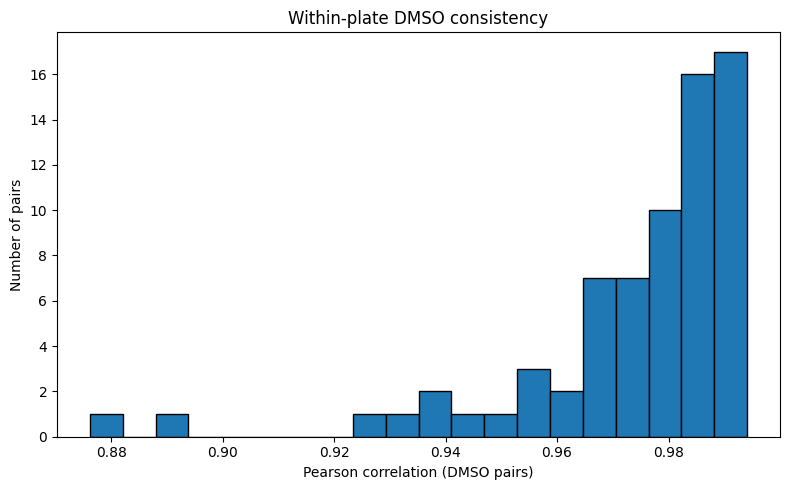

Figure saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/dmso_pair_correlation_histogram.png


In [ ]:
# Matched DMSO consistency QC
# Each plate has two DMSO samples -> compare consistency

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

dmso_results = []

for cell_line in files:

    path = OUT / f"{cell_line}_pseudobulk_raw.h5ad"
    pb = ad.read_h5ad(path)

    # 1. DMSO sample만 선택
    controls = pb.obs.loc[pb.obs["is_control"]].copy()

    assert len(controls) == 28

    # 2. 같은 plate의 DMSO 두 개씩 비교
    for plate, group in controls.groupby("plate", observed=True):

        assert len(group) == 2, (
            f"{cell_line} {plate}: Expected 2 DMSO samples"
        )

        # 해당 DMSO의 matrix row 찾기
        idx = pb.obs.index.get_indexer(group.index)

        X = pb.X[idx, :]

        if sp.issparse(X):
            X = X.toarray()
        else:
            X = np.asarray(X)

        X = X.astype(np.float64)

        # 3. 각 sample의 library size
        library_sizes = X.sum(axis=1)

        assert np.all(library_sizes > 0)

        # 4. QC용 normalization: CPM
        cpm = X / library_sizes[:, None] * 1e6

        log_cpm = np.log2(cpm + 1)

        # 5. 적어도 한 DMSO에서 CPM >= 1인 유전자
        expressed = (cpm >= 1).any(axis=0)

        n_genes = int(expressed.sum())

        # 6. Pearson correlation
        if n_genes >= 100:

            x = log_cpm[0, expressed]
            y = log_cpm[1, expressed]

            if x.std() > 0 and y.std() > 0:
                corr = np.corrcoef(x, y)[0, 1]
            else:
                corr = np.nan

            # 유전자별 발현 차이의 요약
            median_abs_diff = np.median(np.abs(x - y))

        else:
            corr = np.nan
            median_abs_diff = np.nan

        # 7. 결과 저장
        dmso_results.append({
            "cell_line": cell_line,
            "plate": str(plate),
            "sample_1": str(group["sample"].iloc[0]),
            "sample_2": str(group["sample"].iloc[1]),
            "n_cells_1": int(group["n_cells"].iloc[0]),
            "n_cells_2": int(group["n_cells"].iloc[1]),
            "n_genes_compared": n_genes,
            "pearson_r": corr,
            "median_abs_logcpm_diff": median_abs_diff
        })

    del pb


# Summary
dmso_qc = pd.DataFrame(dmso_results)

assert len(dmso_qc) == 70

assert (
    dmso_qc.groupby("cell_line").size() == 14
).all()

print("Total DMSO pairs:", len(dmso_qc))

print("\nCorrelation summary by cell line:")

display(
    dmso_qc.groupby("cell_line").agg(
        n_pairs=("pearson_r", "size"),
        median_r=("pearson_r", "median"),
        min_r=("pearson_r", "min"),
        max_r=("pearson_r", "max"),
        median_abs_diff=(
            "median_abs_logcpm_diff", "median"
        )
    ).round(4)
)

print("\nLowest correlation pairs:")

display(
    dmso_qc.sort_values("pearson_r").head(10)
)

print("\nPairs with undefined correlation:")

display(
    dmso_qc.loc[dmso_qc["pearson_r"].isna()]
)

# Save

csv_path = OUT / "dmso_pair_consistency_qc.csv"

dmso_qc.to_csv(csv_path, index=False)

print("\nSaved:", csv_path)


# Correlation distribution plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    dmso_qc["pearson_r"].dropna(),
    bins=20,
    edgecolor="black"
)

ax.set_xlabel("Pearson correlation (DMSO pairs)")
ax.set_ylabel("Number of pairs")
ax.set_title("Within-plate DMSO consistency")

plt.tight_layout()

fig_path = OUT / "dmso_pair_correlation_histogram.png"

fig.savefig(fig_path, dpi=180, bbox_inches="tight")

plt.show()
plt.close(fig)

print("Figure saved:", fig_path)

In [ ]:
# Flag: HepG2/C3A · Plate 3 / HepG2/C3A · Plate 7 / BT-474 · Plate 7  (also low cell number)
# Especially plate7 showed low correlation in 4 cell lines

In [ ]:
# Low-correlation DMSO pairs: QC detail

flagged = (
    ((pb_qc["cell_line"] == "HepG2_C3A") &
     pb_qc["plate"].isin(["plate3", "plate7"]))
    |
    ((pb_qc["cell_line"] == "BT474") &
     (pb_qc["plate"] == "plate7"))
)

display(
    pb_qc.loc[
        flagged & pb_qc["is_control"],
        [
            "cell_line",
            "plate",
            "sample",
            "n_cells",
            "total_umi",
            "umi_per_cell",
            "n_genes_detected"
        ]
    ].sort_values(["cell_line", "plate", "sample"])
)

,cell_line,plate,sample,n_cells,total_umi,umi_per_cell,n_genes_detected
356,BT474,plate7,smp_2165,400,720003,1800.007500,18265
357,BT474,plate7,smp_2166,480,881311,1836.064583,19337
250,HepG2_C3A,plate3,smp_1781,316,467920,1480.759494,17548
249,HepG2_C3A,plate3,smp_1782,332,497520,1498.554217,18220
190,HepG2_C3A,plate7,smp_2165,282,440182,1560.929078,16472
187,HepG2_C3A,plate7,smp_2166,405,637178,1573.279012,17771


In [ ]:
# umi per cell is similar for each pair; keep these 3 pairs for further analysis but should be considered as flag pairs

# Normalization using pyDEseq2

In [ ]:
%pip install -q "pydeseq2==0.5.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 655.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 2.7 MB/s eta 0:00:00


In [ ]:
# HT-29 pseudobulk normalization
# PyDESeq2 median-of-ratios
# size factor: 샘플마다 RNA count를 얼마나 조정해야 공정하게 비교할 수 있는지 알려주는 보정 계수
# (유전자 발현량마다 샘플 전체에서 기하평균 계산 -> 기준대비 몇배인지 각 샘플에서 계산한 뒤, 그 수천개 유전자의 비율의 중앙값이 size factor)

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp

from pydeseq2.preprocessing import deseq2_norm

# 1. 저장된 HT-29 pseudobulk 불러오기
path = OUT / "HT29_pseudobulk_raw.h5ad"

pb = ad.read_h5ad(path)

print("Input shape:", pb.shape)

assert pb.n_obs == 84

# 2. Raw counts 준비
X = pb.X.toarray() if sp.issparse(pb.X) else np.asarray(pb.X)

assert np.all(X >= 0)
assert np.all(X == np.rint(X))

# 3. Size factor 추정에 사용 가능한 유전자 수 확인
# 기본 median-of-ratios에서는 모든 샘플에서
# count가 0보다 큰 유전자들이 기준으로 사용됨.

reference_genes = np.all(X > 0, axis=0)

n_reference = int(reference_genes.sum())

print("Genes available for size factor estimation:", n_reference)

# 기준 유전자가 지나치게 적으면 진행을 중단하고
# poscounts 등 다른 방법을 검토
# 1000은 공식적인 통계 기준이 아닌 보수적인 점검값
if n_reference < 1000:
    raise ValueError(
        "Few reference genes. Inspect the data before "
        "considering poscounts normalization."
    )

# 4. PyDESeq2 normalization
norm_counts, size_factors = deseq2_norm(X)

size_factors = np.asarray(size_factors).ravel()

# 5. 검증
assert len(size_factors) == pb.n_obs

assert np.all(np.isfinite(size_factors))
assert np.all(size_factors > 0)

assert norm_counts.shape == X.shape
assert np.all(np.isfinite(norm_counts))

# 6. 원본 counts를 유지하면서 결과 저장
pb.obs["size_factor"] = size_factors

pb.var["used_for_size_factor"] = reference_genes

pb.layers["normed_counts"] = np.asarray(
    norm_counts,
    dtype=np.float32
)

output = OUT / "HT29_pseudobulk_normalized.h5ad"

pb.write_h5ad(output, compression="gzip")

print("\nNormalization completed")
print("Saved:", output)

# 7. Size factor QC
sf_qc = pb.obs[
    [
        "plate",
        "sample",
        "drug",
        "concentration",
        "is_control",
        "n_cells",
        "size_factor"
    ]
].copy()

sf_qc["total_umi"] = X.sum(axis=1)

print("\nSize factor summary:")
display(sf_qc["size_factor"].describe())

print("\nSmallest size factors:")
display(sf_qc.nsmallest(5, "size_factor"))

print("\nLargest size factors:")
display(sf_qc.nlargest(5, "size_factor"))

Input shape: (84, 62710)
Genes available for size factor estimation: 13660

Normalization completed
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HT29_pseudobulk_normalized.h5ad

Size factor summary:


count    84.000000
mean      1.149324
std       0.563625
min       0.335709
25%       0.669677
50%       1.036632
75%       1.546646
max       2.621486
Name: size_factor, dtype: float64


Smallest size factors:


,plate,sample,drug,concentration,is_control,n_cells,size_factor,total_umi
HT29__plate3__smp_1768,plate3,smp_1768,Methylprednisolone succinate,5.00,False,657,0.335709,1033498
HT29__plate7__smp_2165,plate7,smp_2165,DMSO_TF,NaN,True,736,0.351219,1117648
HT29__plate5__smp_1920,plate5,smp_1920,Thymol,0.50,False,693,0.355718,1146576
HT29__plate7__smp_2146,plate7,smp_2146,Menadione,0.05,False,761,0.370081,1196174
HT29__plate9__smp_2353,plate9,smp_2353,Niclosamide (olamine),5.00,False,628,0.381477,1284424



Largest size factors:


,plate,sample,drug,concentration,is_control,n_cells,size_factor,total_umi
HT29__plate12__smp_2558,plate12,smp_2558,Bicalutamide,5.0,False,2976,2.621486,8789630
HT29__plate6__smp_2070,plate6,smp_2070,DMSO_TF,NaN,True,2526,2.540290,8682762
HT29__plate2__smp_1685,plate2,smp_1685,DMSO_TF,NaN,True,3006,2.501796,9190402
HT29__plate12__smp_2557,plate12,smp_2557,Omeprazole,5.0,False,2931,2.196531,7296646
HT29__plate8__smp_2257,plate8,smp_2257,Niclosamide (olamine),0.5,False,2944,2.161909,6998643


In [ ]:
# Pilot treatment response: HT-29 0.05

# 1. Treatment 선택
treatment = pb.obs.loc[
    (pb.obs["plate"] == "plate4") &
    (pb.obs["drug"] == "Chlorhexidine (diacetate)") &
    (pb.obs["concentration"] == 0.05) &
    (~pb.obs["is_control"])
]

# 2. Matched DMSO 선택
control = pb.obs.loc[
    (pb.obs["plate"] == "plate4") &
    (pb.obs["is_control"])
]

assert len(treatment) == 1
assert len(control) == 2

# 3. Matrix index
t_idx = pb.obs.index.get_indexer(treatment.index)[0]
c_idx = pb.obs.index.get_indexer(control.index)

# 4. 정규화된 발현량
norm = pb.layers["normed_counts"]

drug_expr = np.asarray(
    norm[t_idx, :]
).ravel()

dmso_expr = np.asarray(
    norm[c_idx, :]
).mean(axis=0)

# 5. Exploratory log2FC
log2fc = np.log2(
    (drug_expr + 1) / (dmso_expr + 1)
)

# 6. 결과 테이블
result = pd.DataFrame({
    "gene": pb.var_names,
    "gene_symbol": pb.var["gene_symbol"].to_numpy(),

    # 정규화된 발현량
    "drug_expression": drug_expr,
    "dmso_expression": dmso_expr,

    # 발현 변화
    "log2FC": log2fc,

    # 원본 UMI counts
    "drug_raw_count": X[t_idx, :],
    "dmso_raw_count": X[c_idx, :].sum(axis=0),
    "total_raw_count": (
        X[t_idx, :] + X[c_idx, :].sum(axis=0)
    )
})

# 파일에는 전체 유전자를 보존하고,
# 출력에서는 raw count 합계가 10 이상인 유전자만 확인. (Pilot에서 발현량이 충분한 유전자부터 확인)
# 이 기준은 pilot용이며 최종 DE 필터는 아님.
result["pilot_expression_filter"] = (   # 양쪽 조건에서 정규화된 발현량이 10 이상인 유전자 확인
    (result["drug_expression"] >= 10) &
    (result["dmso_expression"] >= 10)
)

# 7. 결과 저장
output = OUT / "HT29_Chlorhexidine_0.05_pilot_log2FC.csv"

result.to_csv(output, index=False)

print("Saved:", output)

print("\nGenes passing pilot expression filter:")
print(result["pilot_expression_filter"].sum())

filtered = result.loc[
    result["pilot_expression_filter"]
]

show_cols = [
    "gene",
    "gene_symbol",
    "drug_expression",
    "dmso_expression",
    "log2FC"
]

print("\nTop 10 increased genes:")
display(
    filtered.nlargest(10, "log2FC")[show_cols]
)

print("\nTop 10 decreased genes:")
display(
    filtered.nsmallest(10, "log2FC")[show_cols]
)

Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HT29_Chlorhexidine_0.05_pilot_log2FC.csv

Genes passing pilot expression filter:
12771

Top 10 increased genes:


,gene,gene_symbol,drug_expression,dmso_expression,log2FC
9763,ENSG00000154479,CFAP210,47.813919,17.312904,1.414432
61087,ENSG00000289293,ENSG00000289293,57.737560,21.381172,1.391998
51109,ENSG00000271503,CCL5,77.584846,31.282688,1.283490
9415,ENSG00000151575,TEX9,36.988125,14.940765,1.252828
42498,ENSG00000255150,EID3,38.792423,15.706076,1.252121
14452,ENSG00000178338,ZNF354B,29.770931,11.938519,1.249896
40772,ENSG00000253106,ENSG00000253106,33.379528,13.598604,1.235719
35995,ENSG00000241743,XACT,39.694572,16.595114,1.209662
12542,ENSG00000169245,CXCL10,27.966631,11.685328,1.191231
5560,ENSG00000124659,TBCC,27.064482,11.296935,1.190447



Top 10 decreased genes:


,gene,gene_symbol,drug_expression,dmso_expression,log2FC
19348,ENSG00000202198,7SK,218.320160,1273.641846,-2.538982
23033,ENSG00000215182,MUC5AC,183.136322,816.322693,-2.150131
4764,ENSG00000117983,MUC5B,24.358034,96.785583,-1.947179
1697,ENSG00000086548,CEACAM6,61.346161,215.441498,-1.795605
3094,ENSG00000105388,CEACAM5,87.508492,280.626465,-1.669895
176,ENSG00000007306,CEACAM7,36.988125,115.735619,-1.619624
16977,ENSG00000196154,S100A4,24.358034,73.479660,-1.554404
12678,ENSG00000169876,MUC17,26.162333,75.899315,-1.501363
12641,ENSG00000169710,FASN,103.747185,283.733582,-1.442701
721,ENSG00000054179,ENTPD2,16.238689,45.410622,-1.428805


In [ ]:
# 해석: 중요한 건 개별 유전자 하나의 변화보다 **비슷한 생물학적 기능을 가진 유전자들이 같은 방향으로 움직이는가?**
# HT-29 (colon) · Chlorhexidine 0.05 µM
# 1. Chemokine / inflammatory-associated genes: increase in CCL5, CXCL10
# 2. Mucin-associated genes: decrease in MUC5AC, MUC5B, MUC17 (mucin: 점액의 주요 구성 성분, 점막 보호 및 윤활작용하는 당단백질  - e.g. 장 점막에서는 Goblet cell 감소 → MUC2 감소 → 점액 장벽 약화 → 세균의 상피 접근 증가 → 염증 악화라는 흐름)
# 3. CEACAM family: decrease in CEACAM5, CEACAM6, CEACAM7 (CEACA<5: 세포 접착과 관련된 세포 표면 단백질, 세포 분화 및 극성과 연관)
# 4. Lipid synthesis candidate: decreasze in FASN (FASN: 지방산 합성에 관여하는 효소를 암호화하는 유전자)

# Mucin 관련 유전자들과 CEACAM family가 동시에 감소하고 있기 때문에, Chlorhexidine이 HT-29의 상피세포 관련 발현 프로그램을 변화시켰을 가능성을 고려할 수 있어.
# 그러나 이것이 실제로 세포 분화 상태가 변했다는 뜻인지, 해당 유전자들을 많이 발현하던 세포 집단의 비율이 감소한 것인지는 아직 구별할 수 없어.
# -> single cell level에서 다시 확인 가능하다고 함

# c.f. 7SK: 일반적인 단백질 암호화 mRNA가 아니라, 전사 신장 조절 등에 관여하는 small nuclear RNA (다른 protein-coding gene처럼 해석하면 X)
# 향후 pathway 분석에서는 gene annotation에 따라 protein-coding gene 중심의 분석을 별도로 수행하는 방향으로.

In [ ]:
# Normalize remaining 4 cell lines

import gc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp

from pydeseq2.preprocessing import deseq2_norm

remaining = ["PANC1", "HepG2_C3A", "A172", "BT474"]

norm_summary = []

for cell_line in remaining:

    print(f"\n{'=' * 50}")
    print(f"Processing: {cell_line}")

    input_path = OUT / f"{cell_line}_pseudobulk_raw.h5ad"

    output_path = OUT / f"{cell_line}_pseudobulk_normalized.h5ad"

    # 이미 생성한 정규화 결과는 재계산하지 않음
    if output_path.exists():
        print("Already normalized. Skipping.")
        continue

    # 1. Raw pseudobulk 불러오기
    pb = ad.read_h5ad(input_path)

    assert pb.n_obs == 84
    assert pb.var_names.is_unique

    # 2. Raw counts 준비
    X = (
        pb.X.toarray()
        if sp.issparse(pb.X)
        else np.asarray(pb.X)
    )

    assert np.all(X >= 0)
    assert np.all(X == np.rint(X))

    # 3. Size factor 기준 유전자 확인
    reference_genes = np.all(X > 0, axis=0)

    n_reference = int(reference_genes.sum())

    print("Reference genes:", n_reference)

    if n_reference == 0:
        raise ValueError(
            f"{cell_line}: No reference genes. "
            "Inspect normalization strategy."
        )

    # 4. DESeq2-style normalization
    norm_counts, size_factors = deseq2_norm(X)

    size_factors = np.asarray(size_factors).ravel()

    # 5. 검증
    assert norm_counts.shape == X.shape

    assert np.all(np.isfinite(size_factors))
    assert np.all(size_factors > 0)
    assert np.all(np.isfinite(norm_counts))

    # 6. 결과 저장
    pb.obs["size_factor"] = size_factors

    pb.var["used_for_size_factor"] = reference_genes

    pb.layers["normed_counts"] = np.asarray(
        norm_counts,
        dtype=np.float32
    )

    pb.write_h5ad(
        output_path,
        compression="gzip"
    )

    # 7. QC summary
    norm_summary.append({
        "cell_line": cell_line,
        "n_samples": pb.n_obs,
        "n_reference_genes": n_reference,
        "min_size_factor": size_factors.min(),
        "median_size_factor": np.median(size_factors),
        "max_size_factor": size_factors.max()
    })

    print("Saved:", output_path)

    del pb, X, norm_counts, size_factors
    gc.collect()


# 전체 정규화 결과 요약
norm_summary = pd.DataFrame(norm_summary)

print("\nNormalization summary:")

display(norm_summary)

# 5개 세포주 파일 존재 여부 확인
print("\nNormalized files:")

for cell_line in files:

    path = OUT / f"{cell_line}_pseudobulk_normalized.h5ad"

    print(cell_line, ":", path.exists())


Processing: PANC1
Reference genes: 16739
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/PANC1_pseudobulk_normalized.h5ad

Processing: HepG2_C3A
Reference genes: 10181
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HepG2_C3A_pseudobulk_normalized.h5ad

Processing: A172
Reference genes: 13926
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/A172_pseudobulk_normalized.h5ad

Processing: BT474
Reference genes: 11206
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/BT474_pseudobulk_normalized.h5ad

Normalization summary:


,cell_line,n_samples,n_reference_genes,min_size_factor,median_size_factor,max_size_factor
0,PANC1,84,16739,0.249243,1.063004,3.391596
1,HepG2_C3A,84,10181,0.170505,1.090405,3.933734
2,A172,84,13926,0.231877,1.109146,3.940236
3,BT474,84,11206,0.088653,1.079596,3.839270



Normalized files:
HT29 : True
PANC1 : True
HepG2_C3A : True
A172 : True
BT474 : True


In [ ]:
# All-treatment matched-DMSO response

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import gc

response_summary = []
reference_genes = None

for cell_line in files:

    print(f"\n{'=' * 50}")
    print("Processing:", cell_line)

    # 1. 정규화된 pseudobulk 불러오기
    path = OUT / f"{cell_line}_pseudobulk_normalized.h5ad"

    pb = ad.read_h5ad(path)

    assert pb.n_obs == 84
    assert "normed_counts" in pb.layers

    # 유전자 순서 확인
    if reference_genes is None:
        reference_genes = pb.var_names.copy()
    else:
        assert pb.var_names.equals(reference_genes)

    # 2. 정규화된 발현량
    norm = pb.layers["normed_counts"]

    if sp.issparse(norm):
        norm = norm.toarray()

    norm = np.asarray(norm, dtype=np.float64)

    assert np.isfinite(norm).all()
    assert (norm >= 0).all()

    # 3. 결과 저장용
    response_rows = []
    response_meta = []

    # 4. Plate별 처리
    for plate, plate_obs in pb.obs.groupby(
        "plate",
        observed=True,
        sort=False
    ):

        # 동일 plate의 DMSO
        dmso = plate_obs.loc[
            plate_obs["is_control"]
        ]

        # 동일 plate의 treatment
        treatments = plate_obs.loc[
            ~plate_obs["is_control"]
        ]

        assert len(dmso) == 2, (
            f"{cell_line} {plate}: DMSO count mismatch"
        )

        # 5. DMSO의 행 위치
        c_idx = pb.obs.index.get_indexer(dmso.index)

        # DMSO 정규화 발현량 평균
        dmso_mean = norm[c_idx, :].mean(axis=0)

        # 6. Treatment 하나씩 비교
        for sample_id, row in treatments.iterrows():

            t_idx = pb.obs.index.get_loc(sample_id)

            drug_expr = norm[t_idx, :]

            # Exploratory log2FC
            log2fc = np.log2(
                (drug_expr + 1) / (dmso_mean + 1)
            )

            assert np.isfinite(log2fc).all()

            response_rows.append(
                log2fc.astype(np.float32)
            )

            # 결과의 metadata 보존
            info = row.to_dict()

            info["pseudobulk_id"] = sample_id

            info["matched_dmso_samples"] = ", ".join(
                dmso["sample"].astype(str)
            )

            info["n_matched_dmso"] = len(dmso)

            info["n_matched_dmso_cells"] = int(
                dmso["n_cells"].sum()
            )

            response_meta.append(info)

    # 7. Response AnnData 생성
    response_matrix = np.vstack(response_rows)

    response_obs = (
        pd.DataFrame(response_meta)
        .set_index("pseudobulk_id")
    )

    response = ad.AnnData(
        X=response_matrix,
        obs=response_obs,
        var=pb.var[["gene_symbol"]].copy()
    )

    # 분석 방식 기록
    response.uns["matrix_type"] = "exploratory_log2FC"

    response.uns["normalization"] = (
        "PyDESeq2 median-of-ratios, per cell line"
    )

    response.uns["reference"] = (
        "Cell-line and plate-matched DMSO mean"
    )

    response.uns["pseudocount"] = 1.0

    response.uns["statistical_test"] = "none"

    # 8. 검증
    assert response.n_obs == 56

    assert response.n_vars == pb.n_vars

    assert response.obs["is_control"].eq(False).all()

    assert response.obs["n_matched_dmso"].eq(2).all()

    assert response.obs["concentration"].notna().all()

    # 9. 저장
    output = OUT / f"{cell_line}_plate_level_log2FC.h5ad"

    response.write_h5ad(
        output,
        compression="gzip"
    )

    print("Response shape:", response.shape)
    print("Saved:", output)

    response_summary.append(
        response.obs.reset_index()
    )

    del pb, norm, response, response_matrix
    gc.collect()


# 전체 결과 확인

response_table = pd.concat(
    response_summary,
    ignore_index=True
)

assert len(response_table) == 280

n_conditions = len(
    response_table[
        ["cell_line", "drug", "concentration"]
    ].drop_duplicates()
)

assert n_conditions == 255

print("\nTotal plate-level responses:", len(response_table))
print("Unique treatment conditions:", n_conditions)

print("\nResponses by cell line:")

display(
    response_table.groupby("cell_line").size()
)

# Metadata 저장
summary_path = OUT / "plate_level_response_metadata.csv"

response_table.to_csv(
    summary_path,
    index=False
)

print("\nMetadata saved:", summary_path)


Processing: HT29
Response shape: (56, 62710)
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HT29_plate_level_log2FC.h5ad

Processing: PANC1
Response shape: (56, 62710)
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/PANC1_plate_level_log2FC.h5ad

Processing: HepG2_C3A
Response shape: (56, 62710)
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/HepG2_C3A_plate_level_log2FC.h5ad

Processing: A172
Response shape: (56, 62710)
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/A172_plate_level_log2FC.h5ad

Processing: BT474
Response shape: (56, 62710)
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/BT474_plate_level_log2FC.h5ad

Total plate-level responses: 280
Unique treatment conditions: 255

Responses by cell line:


cell_line
A172         56
BT474        56
HT29         56
HepG2_C3A    56
PANC1        56
dtype: int64


Metadata saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/plate_level_response_metadata.csv


In [ ]:
# Repeated treatment response consistency
# There were some conditions with two replicates (n=25), so check consistency for these cases

import anndata as ad
import numpy as np
import pandas as pd

repeat_qc = []

for cell_line in files:

    response = ad.read_h5ad(
        OUT / f"{cell_line}_plate_level_log2FC.h5ad"
    )

    pb = ad.read_h5ad(
        OUT / f"{cell_line}_pseudobulk_normalized.h5ad"
    )

    norm = np.asarray(pb.layers["normed_counts"])

    # 같은 drug × concentration이 두 plate에 존재하는 경우
    groups = response.obs.groupby(
        ["drug", "concentration"],
        observed=True
    )

    for (drug, dose), group in groups:

        if len(group) == 1:
            continue

        assert len(group) == 2

        group = group.sort_values("plate")

        ids = group.index.tolist()

        idx = response.obs.index.get_indexer(ids)

        fc1, fc2 = np.asarray(
            response.X[idx, :],
            dtype=np.float64
        )

        # 비교할 유전자의 발현 수준 확인
        expression_sum = np.zeros(response.n_vars)

        for sample_id in ids:

            plate = response.obs.loc[sample_id, "plate"]

            t_idx = pb.obs.index.get_loc(sample_id)

            dmso = pb.obs.loc[
                (pb.obs["plate"] == plate) &
                (pb.obs["is_control"])
            ]

            assert len(dmso) == 2

            c_idx = pb.obs.index.get_indexer(dmso.index)

            expression_sum += (
                norm[t_idx, :] +
                norm[c_idx, :].mean(axis=0)
            )

        # 두 plate의 treatment/DMSO 발현 평균
        expressed = (expression_sum / 4) >= 10

        x = fc1[expressed]
        y = fc2[expressed]

        # 전체 response similarity
        if len(x) >= 100 and x.std() > 0 and y.std() > 0:
            r = np.corrcoef(x, y)[0, 1]
            median_diff = np.median(np.abs(x - y))
        else:
            r = np.nan
            median_diff = np.nan

        # 양쪽 plate 모두 |log2FC| >= 1인 유전자 (strong direction agreement)
        strong = (np.abs(x) >= 1) & (np.abs(y) >= 1)

        if strong.sum() > 0:
            direction_agreement = np.mean(
                np.sign(x[strong]) == np.sign(y[strong])
            )
        else:
            direction_agreement = np.nan

        repeat_qc.append({
            "cell_line": cell_line,
            "drug": str(drug),
            "concentration": dose,
            "plates": ", ".join(group["plate"].astype(str)),
            "n_genes_compared": len(x),
            "pearson_r": r,
            "median_abs_log2FC_diff": median_diff,
            "n_strong_both": int(strong.sum()),
            "strong_direction_agreement": direction_agreement
        })


# 결과 정리
repeat_qc = pd.DataFrame(repeat_qc)

assert len(repeat_qc) == 25

print("Repeated conditions:", len(repeat_qc))

print("\nOverall summary:")
display(
    repeat_qc[
        [
            "pearson_r",
            "median_abs_log2FC_diff",
            "strong_direction_agreement"
        ]
    ].describe()
)

print("\nLowest response correlations:")
display(
    repeat_qc.sort_values("pearson_r").head(10)
)

print("\nAll repeated conditions:")
display(repeat_qc)

# 저장
output = OUT / "repeated_treatment_consistency_qc.csv"

repeat_qc.to_csv(output, index=False)

print("\nSaved:", output)

Repeated conditions: 25

Overall summary:


,pearson_r,median_abs_log2FC_diff,strong_direction_agreement
count,25.000000,25.000000,25.000000
mean,0.340594,0.234969,0.858124
std,0.210462,0.039151,0.218241
min,-0.059437,0.183645,0.318182
25%,0.284522,0.210818,0.918033
50%,0.412641,0.221402,0.960000
75%,0.484149,0.249912,0.984848
max,0.608762,0.315554,1.000000



Lowest response correlations:


,cell_line,drug,concentration,plates,n_genes_compared,pearson_r,median_abs_log2FC_diff,n_strong_both,strong_direction_agreement
0,HT29,Chlorhexidine (diacetate),0.5,"plate5, plate13",13175,-0.059437,0.315554,22,0.318182
10,HepG2_C3A,Chlorhexidine (diacetate),0.5,"plate5, plate13",10822,-0.054435,0.309711,14,0.500000
20,BT474,Chlorhexidine (diacetate),0.5,"plate5, plate13",12200,-0.038486,0.303465,18,0.388889
15,A172,Chlorhexidine (diacetate),0.5,"plate5, plate13",14101,-0.017702,0.292429,21,0.476190
5,PANC1,Chlorhexidine (diacetate),0.5,"plate5, plate13",16266,-0.010433,0.285447,34,0.529412
12,HepG2_C3A,Thymol,5.0,"plate6, plate14",10891,0.280536,0.249912,20,1.000000
7,PANC1,Thymol,5.0,"plate6, plate14",16514,0.284522,0.219605,60,0.816667
22,BT474,Thymol,5.0,"plate6, plate14",12268,0.311660,0.248773,39,0.948718
2,HT29,Thymol,5.0,"plate6, plate14",13483,0.315834,0.258549,61,0.918033
17,A172,Thymol,5.0,"plate6, plate14",14321,0.362721,0.208951,25,0.960000



All repeated conditions:


,cell_line,drug,concentration,plates,n_genes_compared,pearson_r,median_abs_log2FC_diff,n_strong_both,strong_direction_agreement
0,HT29,Chlorhexidine (diacetate),0.5,"plate5, plate13",13175,-0.059437,0.315554,22,0.318182
1,HT29,Chlorhexidine (diacetate),5.0,"plate6, plate14",13531,0.412641,0.210818,41,1.000000
2,HT29,Thymol,5.0,"plate6, plate14",13483,0.315834,0.258549,61,0.918033
3,HT29,Triamcinolone,5.0,"plate6, plate14",13451,0.542756,0.214168,133,0.992481
4,HT29,Triclosan,5.0,"plate6, plate14",13535,0.395751,0.221827,59,0.966102
5,PANC1,Chlorhexidine (diacetate),0.5,"plate5, plate13",16266,-0.010433,0.285447,34,0.529412
6,PANC1,Chlorhexidine (diacetate),5.0,"plate6, plate14",16459,0.608762,0.230090,311,0.993569
7,PANC1,Thymol,5.0,"plate6, plate14",16514,0.284522,0.219605,60,0.816667
8,PANC1,Triamcinolone,5.0,"plate6, plate14",16584,0.466034,0.215428,167,0.940120
9,PANC1,Triclosan,5.0,"plate6, plate14",16636,0.401454,0.191086,73,0.958904



Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/repeated_treatment_consistency_qc.csv


In [ ]:
# Chlorhexidine 0.5 µM: pearson_r ~ 0 for all 5 cell lines -> check
# replicate = 1 -> use original plate-level log2FC
# replicate = 2 -> use average log2FC from two plates to make representative signature for exploration (but keep consistency info together)

In [ ]:
# Chlorhexidine 0.5 µM: plate comparison

import anndata as ad
import numpy as np
import pandas as pd

rows = []

for cell_line in files:

    response = ad.read_h5ad(
        OUT / f"{cell_line}_plate_level_log2FC.h5ad"
    )

    pb = ad.read_h5ad(
        OUT / f"{cell_line}_pseudobulk_normalized.h5ad"
    )

    # Chlorhexidine 0.5 µM만 선택
    target = response.obs.loc[
        (response.obs["drug"] == "Chlorhexidine (diacetate)") &
        (response.obs["concentration"] == 0.5)
    ]

    assert len(target) == 2
    assert set(target["plate"]) == {"plate5", "plate13"}

    norm = np.asarray(pb.layers["normed_counts"])

    for sample_id, info in target.iterrows():

        plate = info["plate"]

        # Treatment
        t_idx = pb.obs.index.get_loc(sample_id)

        drug_expr = norm[t_idx, :]

        # Matched DMSO
        dmso = pb.obs.loc[
            (pb.obs["plate"] == plate) &
            (pb.obs["is_control"])
        ]

        assert len(dmso) == 2

        c_idx = pb.obs.index.get_indexer(dmso.index)

        dmso_expr = norm[c_idx, :].mean(axis=0)

        # 발현량이 충분한 유전자만 비교
        expressed = (
            (drug_expr + dmso_expr) / 2 >= 10
        )

        # 기존에 저장된 log2FC
        fc = np.asarray(
            response[sample_id, :].X
        ).ravel()

        fc = fc[expressed]

        rows.append({
            "cell_line": cell_line,
            "plate": plate,
            "sample": info["sample"],
            "n_cells": info["n_cells"],
            "n_genes_compared": len(fc),
            "median_abs_log2FC": np.median(np.abs(fc)),
            "n_up_log2FC_1": int((fc >= 1).sum()),
            "n_down_log2FC_1": int((fc <= -1).sum())
        })

# 결과 정리
chlorhex_check = pd.DataFrame(rows)

display(
    chlorhex_check.sort_values(
        ["cell_line", "plate"]
    )
)

# 저장
chlorhex_check.to_csv(
    OUT / "chlorhexidine_0.5_plate_comparison.csv",
    index=False
)

,cell_line,plate,sample,n_cells,n_genes_compared,median_abs_log2FC,n_up_log2FC_1,n_down_log2FC_1
7,A172,plate13,smp_2657,1441,13864,0.217001,170,133
6,A172,plate5,smp_1880,2930,14258,0.187360,54,103
9,BT474,plate13,smp_2657,1121,12004,0.225361,120,169
8,BT474,plate5,smp_1880,1376,12306,0.191524,47,97
1,HT29,plate13,smp_2657,1831,12792,0.224837,125,138
0,HT29,plate5,smp_1880,1843,13431,0.206729,88,131
5,HepG2_C3A,plate13,smp_2657,776,10568,0.225978,100,144
4,HepG2_C3A,plate5,smp_1880,1422,10985,0.195505,50,53
3,PANC1,plate13,smp_2657,3666,16038,0.208568,124,109
2,PANC1,plate5,smp_1880,3110,16412,0.190059,156,148


In [ ]:
# not consistent possibly because: plate 간 실험 차이, cell-state 구성 차이, 샘플 변동 -> but cannot specify the reason
# keep results from two plates separately for Chlorhexidine 0.5 µM

In [ ]:
# Create condition-level response signatures

import anndata as ad
import numpy as np
import pandas as pd

signature_rows = []
signature_meta = []

reference_genes = None
reference_var = None

for cell_line in files:

    response = ad.read_h5ad(
        OUT / f"{cell_line}_plate_level_log2FC.h5ad"
    )

    # 유전자 순서 확인
    if reference_genes is None:
        reference_genes = response.var_names.copy()
        reference_var = response.var.copy()
    else:
        assert response.var_names.equals(reference_genes)

    # 같은 drug × concentration 묶기
    groups = response.obs.groupby(
        ["drug", "concentration"],
        observed=True,
        sort=False
    )

    for (drug, dose), group in groups:

        idx = response.obs.index.get_indexer(group.index)

        fc = np.asarray(
            response.X[idx, :],
            dtype=np.float64
        )

        n = len(group)

        assert n in [1, 2]

        # --------------------------------------------
        # 1. 단일 plate
        # --------------------------------------------
        if n == 1:

            signature = fc[0]

            status = "single_plate_exploratory"

        # --------------------------------------------
        # 2. Chlorhexidine 0.5 µM: 불일치
        # --------------------------------------------
        elif (
            str(drug) == "Chlorhexidine (diacetate)"
            and np.isclose(float(dose), 0.5)
        ):

            assert set(group["plate"]) == {
                "plate5", "plate13"
            }

            # 대표 signature 생성 보류
            signature = np.full(
                response.n_vars,
                np.nan
            )

            status = "discordant_no_signature"

        # --------------------------------------------
        # 3. 나머지 반복 조건
        # --------------------------------------------
        else:

            assert set(group["plate"]) == {
                "plate6", "plate14"
            }

            signature = fc.mean(axis=0)

            status = "two_plate_mean_exploratory"

        signature_rows.append(
            signature.astype(np.float32)
        )

        signature_meta.append({
            "condition_id": (
                f"{cell_line}__{drug}__{float(dose):g}"
            ),
            "cell_line": cell_line,
            "drug": str(drug),
            "concentration": float(dose),
            "n_plate_profiles": n,
            "plates": ", ".join(
                sorted(group["plate"].astype(str))
            ),
            "source_samples": ", ".join(
                sorted(group["sample"].astype(str))
            ),
            "signature_status": status
        })

    del response


# Create combined AnnData

signature_matrix = np.vstack(signature_rows)

signature_obs = (
    pd.DataFrame(signature_meta)
    .set_index("condition_id")
)

signatures = ad.AnnData(
    X=signature_matrix,
    obs=signature_obs,
    var=reference_var
)

signatures.uns["matrix_type"] = (
    "exploratory_condition_level_log2FC"
)

signatures.uns["statistical_test"] = "none"

signatures.uns["discordant_policy"] = (
    "Chlorhexidine 0.5 uM: signature withheld"
)

# Validation

assert signatures.shape == (255, 62710)

assert signatures.obs.index.is_unique

status_counts = (
    signatures.obs["signature_status"]
    .value_counts()
)

assert status_counts["single_plate_exploratory"] == 230

assert status_counts["two_plate_mean_exploratory"] == 20

assert status_counts["discordant_no_signature"] == 5

# 정상 signature에서 NaN이 없는지 확인
valid = (
    signatures.obs["signature_status"]
    != "discordant_no_signature"
).to_numpy()

assert np.isfinite(
    signatures.X[valid, :]
).all()

assert np.isnan(
    signatures.X[~valid, :]
).all()


# ============================================================
# Save
# ============================================================

output = OUT / "condition_level_log2FC.h5ad"

signatures.write_h5ad(
    output,
    compression="gzip"
)

meta_output = OUT / "condition_level_metadata.csv"

signatures.obs.to_csv(meta_output)

print("Final shape:", signatures.shape)

print("\nSignature status:")
print(status_counts)

print("\nSaved:", output)
print("Saved:", meta_output)

Final shape: (255, 62710)

Signature status:
signature_status
single_plate_exploratory      230
two_plate_mean_exploratory     20
discordant_no_signature         5
Name: count, dtype: int64

Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/condition_level_log2FC.h5ad
Saved: /content/drive/MyDrive/Tahoe_project/results/pseudobulk/condition_level_metadata.csv
